In [1]:
# ============================================================
# CELL 1: Imports and Load Data
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
import os

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
RANDOM_SEED = 42

# Load feature table
customers = pd.read_csv(
    '../data/processed/customer_features.csv',
    parse_dates=['FirstPurchase', 'LastPurchase'],
    dtype={'Customer ID': str}
)

print(f"Loaded: {customers.shape[0]:,} customers × {customers.shape[1]} features")

Loaded: 5,878 customers × 18 features


In [2]:
# ============================================================
# CELL 2: Feature Preparation for Clustering
# ============================================================
# We use RFM + key behavioral features for clustering
# Why not all features? More features can introduce noise
# in distance-based algorithms (curse of dimensionality)
#
# Features selected:
# - Recency: how recently they bought
# - Frequency: how often they buy
# - Monetary: how much they spend
# - AvgOrderValue: their typical order size
# - UniqueProducts: breadth of shopping
# - Tenure: how long they've been a customer
# - ReturnRate: satisfaction signal

CLUSTER_FEATURES = [
    'Recency', 'Frequency', 'Monetary',
    'AvgOrderValue', 'UniqueProducts',
    'Tenure', 'ReturnRate'
]

X = customers[CLUSTER_FEATURES].copy()

# --- Step 1: Log Transform skewed features ---
# Why: K-Means uses Euclidean distance — extreme values dominate
# We add 1 before log to handle zeros (log(0) = undefined)
LOG_FEATURES = ['Frequency', 'Monetary', 'AvgOrderValue',
                'UniqueProducts', 'ReturnRate']

for col in LOG_FEATURES:
    X[col] = np.log1p(X[col])

print("After log transform — skewness:")
for col in CLUSTER_FEATURES:
    print(f"  {col:<20} skew = {X[col].skew():.2f}")

# --- Step 2: Standard Scaling ---
# Why: K-Means is distance-based. Without scaling, Monetary
# (range: £1 to £580K) would completely dominate Recency
# (range: 1 to 738 days). Scaling puts all features on
# the same scale (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=CLUSTER_FEATURES)

print(f"\nAfter scaling — mean and std per feature:")
print(pd.DataFrame({
    'Mean': X_scaled_df.mean().round(4),
    'Std':  X_scaled_df.std().round(4)
}))

After log transform — skewness:
  Recency              skew = 0.89
  Frequency            skew = 1.00
  Monetary             skew = 0.27
  AvgOrderValue        skew = 0.06
  UniqueProducts       skew = -0.28
  Tenure               skew = 0.39
  ReturnRate           skew = 1.77

After scaling — mean and std per feature:
                Mean     Std
Recency         -0.0  1.0001
Frequency        0.0  1.0001
Monetary         0.0  1.0001
AvgOrderValue    0.0  1.0001
UniqueProducts  -0.0  1.0001
Tenure          -0.0  1.0001
ReturnRate       0.0  1.0001


Testing K values...
  K=2: Inertia=25,672 | Silhouette=0.325 | Davies-Bouldin=1.183
  K=3: Inertia=21,727 | Silhouette=0.230 | Davies-Bouldin=1.510
  K=4: Inertia=18,531 | Silhouette=0.247 | Davies-Bouldin=1.324
  K=5: Inertia=16,648 | Silhouette=0.213 | Davies-Bouldin=1.377
  K=6: Inertia=15,260 | Silhouette=0.211 | Davies-Bouldin=1.316
  K=7: Inertia=14,222 | Silhouette=0.217 | Davies-Bouldin=1.371
  K=8: Inertia=13,341 | Silhouette=0.212 | Davies-Bouldin=1.328
  K=9: Inertia=12,595 | Silhouette=0.199 | Davies-Bouldin=1.343
  K=10: Inertia=12,043 | Silhouette=0.197 | Davies-Bouldin=1.359


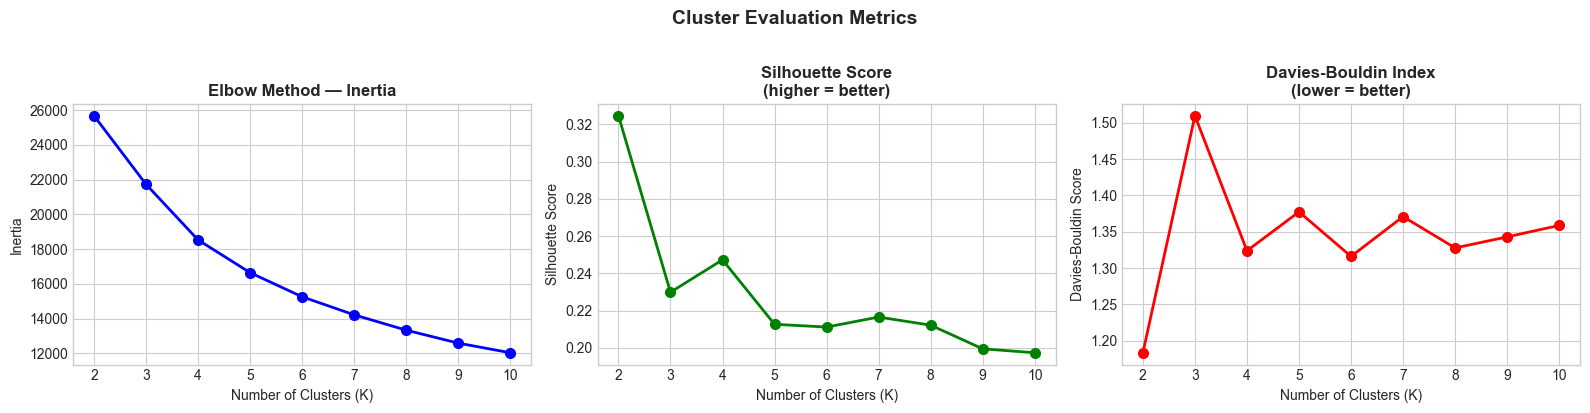


CLUSTER EVALUATION SUMMARY
K       Silhouette   Davies-Bouldin
-----------------------------------
2            0.325 ← best      1.183 ← best
3            0.230             1.510 
4            0.247             1.324 
5            0.213             1.377 
6            0.211             1.316 
7            0.217             1.371 
8            0.212             1.328 
9            0.199             1.343 
10           0.197             1.359 


In [3]:
# ============================================================
# CELL 3: Find Optimal K — Elbow + Silhouette
# ============================================================
# We test K from 2 to 10 and measure:
#
# Inertia (Elbow method):
#   Total distance of each point from its cluster center
#   Lower = tighter clusters, but always decreases with more K
#   We look for the "elbow" — where adding K stops helping much
#
# Silhouette Score:
#   Measures how similar a point is to its own cluster
#   vs other clusters. Range: -1 to 1. Higher = better.
#   This is MORE reliable than the elbow method alone.
#
# Interview tip: Always use BOTH methods and explain why

K_RANGE = range(2, 11)
inertias = []
silhouette_scores = []
davies_bouldin_scores = []

print("Testing K values...")
for k in K_RANGE:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_SEED,
                    n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, labels))
    print(f"  K={k}: Inertia={kmeans.inertia_:,.0f} | "
          f"Silhouette={silhouette_scores[-1]:.3f} | "
          f"Davies-Bouldin={davies_bouldin_scores[-1]:.3f}")

# Plot all three metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Elbow curve
axes[0].plot(K_RANGE, inertias, 'bo-', linewidth=2, markersize=7)
axes[0].set_title('Elbow Method — Inertia', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

# Silhouette scores
axes[1].plot(K_RANGE, silhouette_scores, 'go-', linewidth=2, markersize=7)
axes[1].set_title('Silhouette Score\n(higher = better)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

# Davies-Bouldin scores
axes[2].plot(K_RANGE, davies_bouldin_scores, 'ro-', linewidth=2, markersize=7)
axes[2].set_title('Davies-Bouldin Index\n(lower = better)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Number of Clusters (K)')
axes[2].set_ylabel('Davies-Bouldin Score')

plt.suptitle('Cluster Evaluation Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/08_optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\n" + "=" * 55)
print("CLUSTER EVALUATION SUMMARY")
print("=" * 55)
print(f"{'K':<5} {'Silhouette':>12} {'Davies-Bouldin':>16}")
print("-" * 35)
for i, k in enumerate(K_RANGE):
    best_s = "← best" if silhouette_scores[i] == max(silhouette_scores) else ""
    best_d = "← best" if davies_bouldin_scores[i] == min(davies_bouldin_scores) else ""
    print(f"{k:<5} {silhouette_scores[i]:>12.3f} {best_s:<8} "
          f"{davies_bouldin_scores[i]:>8.3f} {best_d}")

In [4]:
# ============================================================
# CELL 4: Fit Final K-Means Model
# ============================================================
# We'll select K based on the evaluation above
# Default suggestion: K=4 (often optimal for retail RFM)
# But we confirm from the metrics above

# *** AFTER RUNNING CELL 3, set K to the value with
#     highest Silhouette score ***
OPTIMAL_K = 4  # update this after seeing Cell 3 output

kmeans_final = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=RANDOM_SEED,
    n_init=10,
    max_iter=300
)

customers['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"K-Means fitted with K={OPTIMAL_K}")
print(f"\nCluster sizes:")
cluster_sizes = customers['Cluster'].value_counts().sort_index()
for cluster, size in cluster_sizes.items():
    pct = size / len(customers) * 100
    print(f"  Cluster {cluster}: {size:,} customers ({pct:.1f}%)")

K-Means fitted with K=4

Cluster sizes:
  Cluster 0: 1,520 customers (25.9%)
  Cluster 1: 2,031 customers (34.6%)
  Cluster 2: 1,627 customers (27.7%)
  Cluster 3: 700 customers (11.9%)


CLUSTER PROFILES — MEDIAN VALUES
         Recency  Frequency  Monetary  AvgOrderValue  UniqueProducts  Tenure  ReturnRate  CustomerCount  Pct_of_Total  ChurnRate_pct
Cluster                                                                                                                             
0           25.0       11.0   4216.18         366.61           155.0   619.5        0.18           1520          25.9           13.9
1           71.0        3.0    927.03         277.02            50.0   272.0        0.00           2031          34.6           43.5
2          407.0        1.0    216.95         167.40            14.0     0.0        0.00           1627          27.7           84.9
3          291.0        2.0    736.30         328.36            32.0    82.0        0.80            700          11.9           73.1


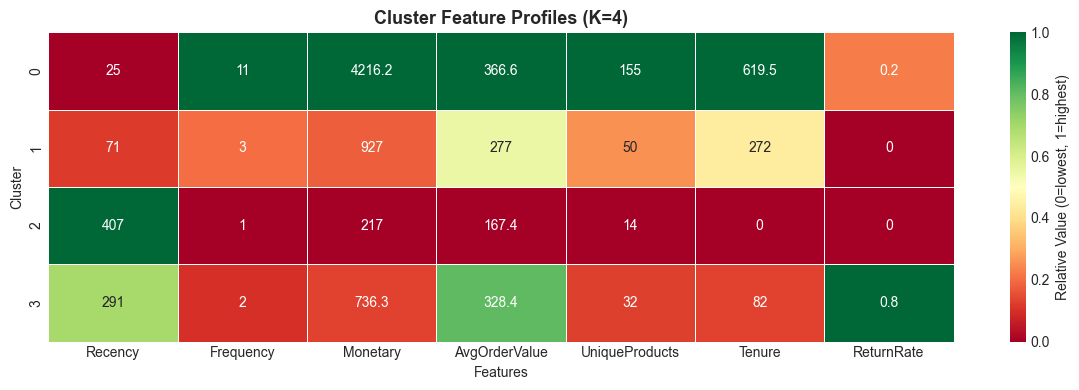

In [5]:
# ============================================================
# CELL 5: Cluster Profiles — Business Interpretation
# ============================================================
# This is what makes segmentation valuable to a business.
# Raw cluster numbers mean nothing. Personas mean everything.
# A cluster profile answers: "Who ARE these customers?"

profile = customers.groupby('Cluster')[CLUSTER_FEATURES].median().round(2)

# Add cluster size
profile['CustomerCount'] = customers['Cluster'].value_counts().sort_index()
profile['Pct_of_Total'] = (profile['CustomerCount'] / len(customers) * 100).round(1)

# Add churn rate per cluster — very useful business insight
churn_by_cluster = customers.groupby('Cluster')['Churned'].mean().round(3) * 100
profile['ChurnRate_pct'] = churn_by_cluster

print("=" * 70)
print("CLUSTER PROFILES — MEDIAN VALUES")
print("=" * 70)
print(profile.to_string())
print("=" * 70)

# Visualize cluster profiles as a heatmap
profile_norm = profile[CLUSTER_FEATURES].copy()

# Normalize for heatmap (0-1 scale per feature)
for col in profile_norm.columns:
    col_min = profile_norm[col].min()
    col_max = profile_norm[col].max()
    if col_max > col_min:
        profile_norm[col] = (profile_norm[col] - col_min) / (col_max - col_min)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    profile_norm,
    annot=profile[CLUSTER_FEATURES].round(1),
    fmt='g',
    cmap='RdYlGn',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Relative Value (0=lowest, 1=highest)'}
)
ax.set_title(f'Cluster Feature Profiles (K={OPTIMAL_K})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Features')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.savefig('../reports/figures/09_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

PCA variance explained:
  PC1: 54.9%
  PC2: 16.7%
  Total: 71.6%


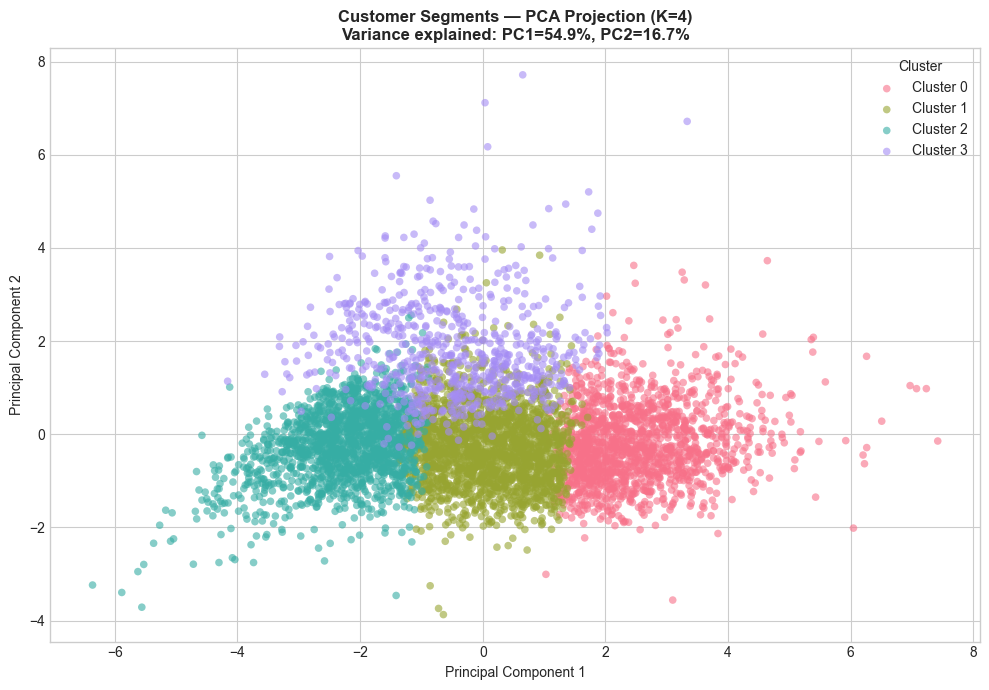

In [6]:
# ============================================================
# CELL 6: PCA Visualization — See the Clusters
# ============================================================
# PCA (Principal Component Analysis) compresses 7 features
# into 2 dimensions so we can PLOT the clusters
#
# Why PCA for visualization only?
# We clustered on 7 features. We can't plot in 7 dimensions.
# PCA finds the 2 directions of maximum variance and projects
# the data onto them — preserving as much structure as possible
#
# Interview tip: "I used PCA for visualization only, not for
# clustering — to avoid losing information"

pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_scaled)

variance_explained = pca.explained_variance_ratio_ * 100
print(f"PCA variance explained:")
print(f"  PC1: {variance_explained[0]:.1f}%")
print(f"  PC2: {variance_explained[1]:.1f}%")
print(f"  Total: {sum(variance_explained):.1f}%")

fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette("husl", OPTIMAL_K)

for cluster in range(OPTIMAL_K):
    mask = customers['Cluster'] == cluster
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=[colors[cluster]], label=f'Cluster {cluster}',
        alpha=0.6, s=30, edgecolors='none'
    )

ax.set_title(f'Customer Segments — PCA Projection (K={OPTIMAL_K})\n'
             f'Variance explained: PC1={variance_explained[0]:.1f}%, '
             f'PC2={variance_explained[1]:.1f}%',
             fontsize=12, fontweight='bold')
ax.set_xlabel(f'Principal Component 1')
ax.set_ylabel(f'Principal Component 2')
ax.legend(title='Cluster', fontsize=10)
plt.tight_layout()
plt.savefig('../reports/figures/10_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ============================================================
# CELL 7: Assign Business Persona Names
# ============================================================
# This is what separates a data scientist from a business analyst
# Numbers become stories. Clusters become people.
#
# HOW TO NAME PERSONAS:
# Look at the cluster profile table from Cell 5:
# - High Monetary + High Frequency + Low Recency = Champions
# - Low Recency (bought recently) + Low Frequency = New Customers
# - High Recency (haven't bought lately) + Low Monetary = At Risk
# - Low everything = Lost/Hibernating
#
# These are STANDARD RFM persona names used in industry
# Adjust based on YOUR cluster profile output

# Standard RFM persona mapping — review and adjust after Cell 5
# The cluster number → persona name mapping depends on your data
PERSONA_NAMES = {
    0: 'Champions',         # Low recency, high frequency, high monetary
    1: 'Loyal Developing',  # Moderate recency, growing value
    2: 'One-Time Lost',     # Very high recency, single purchase, no tenure
    3: 'At Risk'            # High recency, high return rate, fading
}

# *** IMPORTANT: After running Cell 5, look at ChurnRate_pct
#     and median Recency/Frequency/Monetary per cluster.
#     Then reassign the persona names above to match reality ***

customers['Persona'] = customers['Cluster'].map(PERSONA_NAMES)

print("Customer Persona Distribution:")
persona_dist = customers['Persona'].value_counts()
for persona, count in persona_dist.items():
    pct = count / len(customers) * 100
    churn = customers[customers['Persona'] == persona]['Churned'].mean() * 100
    print(f"  {persona:<20} {count:>5,} customers ({pct:.1f}%) | Churn rate: {churn:.1f}%")

# Save updated customer features with cluster labels
customers.to_csv('../data/processed/customer_features.csv', index=False)
print("\nSaved customer features with cluster labels.")
print(f"File: data/processed/customer_features.csv")

Customer Persona Distribution:
  Loyal Developing     2,031 customers (34.6%) | Churn rate: 43.5%
  One-Time Lost        1,627 customers (27.7%) | Churn rate: 84.9%
  Champions            1,520 customers (25.9%) | Churn rate: 13.9%
  At Risk                700 customers (11.9%) | Churn rate: 73.1%

Saved customer features with cluster labels.
File: data/processed/customer_features.csv


Running t-SNE on 3000 customers...
t-SNE complete.


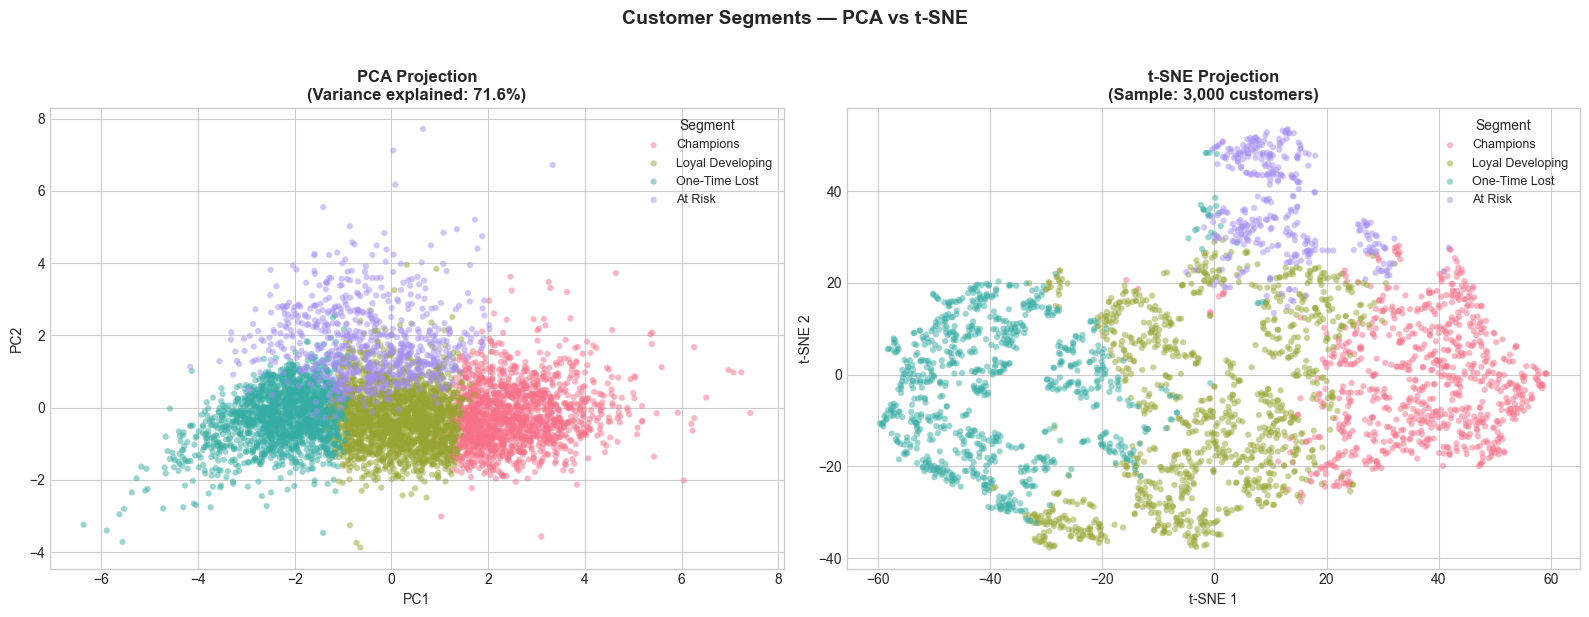

In [8]:
# ============================================================
# CELL 8: t-SNE Visualization
# ============================================================
# t-SNE is another dimensionality reduction technique like PCA
# but NON-LINEAR — it's better at revealing local cluster
# structure that PCA might miss
#
# Key difference from PCA:
# PCA: preserves global structure (distances between clusters)
# t-SNE: preserves local structure (shape within clusters)
#
# Why use both? Shows the clusters from two perspectives.
# Interviewers are impressed when you explain the difference.
#
# WARNING: t-SNE is slow on large datasets. We sample 3,000
# customers for speed without losing representativeness.

TSNE_SAMPLE = min(3000, len(customers))

sample_idx = customers.sample(
    n=TSNE_SAMPLE, random_state=RANDOM_SEED
).index

X_sample = X_scaled[sample_idx]
labels_sample = customers.loc[sample_idx, 'Cluster'].values
personas_sample = customers.loc[sample_idx, 'Persona'].values

print(f"Running t-SNE on {TSNE_SAMPLE} customers...")
tsne = TSNE(
    n_components=2,
    perplexity=40,       # controls local vs global balance
    max_iter=1000,
    random_state=RANDOM_SEED,
    verbose=0
)
X_tsne = tsne.fit_transform(X_sample)
print("t-SNE complete.")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = sns.color_palette("husl", OPTIMAL_K)

persona_list = [PERSONA_NAMES[i] for i in range(OPTIMAL_K)]

# Left: PCA
for cluster in range(OPTIMAL_K):
    mask = customers['Cluster'] == cluster
    axes[0].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=[colors[cluster]],
        label=persona_list[cluster],
        alpha=0.5, s=20, edgecolors='none'
    )
axes[0].set_title(
    f'PCA Projection\n(Variance explained: {sum(variance_explained):.1f}%)',
    fontsize=12, fontweight='bold'
)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(title='Segment', fontsize=9)

# Right: t-SNE
for cluster in range(OPTIMAL_K):
    mask = labels_sample == cluster
    axes[1].scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=[colors[cluster]],
        label=persona_list[cluster],
        alpha=0.5, s=20, edgecolors='none'
    )
axes[1].set_title(
    f't-SNE Projection\n(Sample: {TSNE_SAMPLE:,} customers)',
    fontsize=12, fontweight='bold'
)
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')
axes[1].legend(title='Segment', fontsize=9)

plt.suptitle('Customer Segments — PCA vs t-SNE',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/11_pca_tsne_clusters.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ============================================================
# CELL 9: Segment Business Summary
# ============================================================
# This is what you present to stakeholders.
# Every number becomes a business action recommendation.

print("=" * 65)
print("CUSTOMER SEGMENT SUMMARY — BUSINESS VIEW")
print("=" * 65)

segment_summary = customers.groupby('Persona').agg(
    Customers=('Customer ID', 'count'),
    Avg_Recency=('Recency', 'median'),
    Avg_Frequency=('Frequency', 'median'),
    Avg_Monetary=('Monetary', 'median'),
    Avg_Tenure=('Tenure', 'median'),
    Churn_Rate=('Churned', 'mean')
).round(2)

segment_summary['Churn_Rate'] = (segment_summary['Churn_Rate'] * 100).round(1)
segment_summary['Revenue_Share'] = (
    customers.groupby('Persona')['Monetary'].sum() /
    customers['Monetary'].sum() * 100
).round(1)

print(segment_summary.to_string())

print("\n" + "=" * 65)
print("BUSINESS RECOMMENDATIONS PER SEGMENT")
print("=" * 65)

recommendations = {
    'Champions': (
        "→ Reward with loyalty program, early access to new products.\n"
        "   Lowest churn risk. Focus on retention and upselling."
    ),
    'Loyal Developing': (
        "→ Nurture with personalized offers, cross-sell recommendations.\n"
        "   Mid-range churn risk — engagement campaigns needed."
    ),
    'At Risk': (
        "→ URGENT: Win-back campaigns, special discounts.\n"
        "   High churn risk + high return rate = dissatisfaction signal."
    ),
    'One-Time Lost': (
        "→ Re-engagement email campaign with strong incentive.\n"
        "   Highest churn rate. Low ROI to pursue — filter by value."
    )
}

for segment, rec in recommendations.items():
    count = segment_summary.loc[segment, 'Customers'] if segment in segment_summary.index else 'N/A'
    print(f"\n[{segment}] — {count} customers")
    print(f"  {rec}")

print("\n" + "=" * 65)
print("Saved: data/processed/customer_features.csv (with Persona column)")

CUSTOMER SEGMENT SUMMARY — BUSINESS VIEW
                  Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  Avg_Tenure  Churn_Rate  Revenue_Share
Persona                                                                                                     
At Risk                 700        291.0            2.0        736.30        82.0        73.0            5.8
Champions              1520         25.0           11.0       4216.18       619.5        14.0           78.4
Loyal Developing       2031         71.0            3.0        927.03       272.0        43.0           13.3
One-Time Lost          1627        407.0            1.0        216.95         0.0        85.0            2.5

BUSINESS RECOMMENDATIONS PER SEGMENT

[Champions] — 1520 customers
  → Reward with loyalty program, early access to new products.
   Lowest churn risk. Focus on retention and upselling.

[Loyal Developing] — 2031 customers
  → Nurture with personalized offers, cross-sell recommendations.
   Mid-range ch

In [12]:
# ============================================================
# FIX: Ensure Cluster and Persona are saved to CSV
# ============================================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Reload base features
customers = pd.read_csv(
    '../data/processed/customer_features.csv',
    dtype={'Customer ID': str}
)

CLUSTER_FEATURES = [
    'Recency', 'Frequency', 'Monetary',
    'AvgOrderValue', 'UniqueProducts',
    'Tenure', 'ReturnRate'
]

X = customers[CLUSTER_FEATURES].copy()

LOG_FEATURES = ['Frequency', 'Monetary', 'AvgOrderValue',
                'UniqueProducts', 'ReturnRate']
for col in LOG_FEATURES:
    X[col] = np.log1p(X[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Refit K-Means with K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10, max_iter=300)
customers['Cluster'] = kmeans.fit_predict(X_scaled)

# Assign personas based on confirmed profiles
PERSONA_NAMES = {
    0: 'Champions',
    1: 'Loyal Developing',
    2: 'One-Time Lost',
    3: 'At Risk'
}

customers['Persona'] = customers['Cluster'].map(PERSONA_NAMES)

# Verify before saving
print("Cluster distribution:")
print(customers['Cluster'].value_counts().sort_index())
print("\nPersona distribution:")
print(customers['Persona'].value_counts())
print(f"\nColumns: {customers.columns.tolist()}")

# Save
customers.to_csv('../data/processed/customer_features.csv', index=False)
print("\nSaved successfully with Cluster and Persona columns.")

Cluster distribution:
Cluster
0    1520
1    2031
2    1627
3     700
Name: count, dtype: int64

Persona distribution:
Persona
Loyal Developing    2031
One-Time Lost       1627
Champions           1520
At Risk              700
Name: count, dtype: int64

Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'AvgBasketSize', 'UniqueProducts', 'ReturnCount', 'Tenure', 'FirstPurchase', 'LastPurchase', 'PreferredDayOfWeek', 'PreferredMonth', 'ReturnRate', 'Country', 'Churned', 'Cluster', 'Persona']

Saved successfully with Cluster and Persona columns.


In [11]:
# Verify cluster profiles before naming
profile_check = customers.groupby('Cluster')[
    ['Recency', 'Frequency', 'Monetary', 'Tenure', 'ReturnRate']
].median().round(2)
profile_check['Count'] = customers['Cluster'].value_counts().sort_index()
profile_check['ChurnRate'] = (customers.groupby('Cluster')['Churned'].mean() * 100).round(1)
print(profile_check.to_string())

         Recency  Frequency  Monetary  Tenure  ReturnRate  Count  ChurnRate
Cluster                                                                    
0           25.0       11.0   4216.18   619.5        0.18   1520       13.9
1           71.0        3.0    927.03   272.0        0.00   2031       43.5
2          407.0        1.0    216.95     0.0        0.00   1627       84.9
3          291.0        2.0    736.30    82.0        0.80    700       73.1
